### **D1 — Revenue Overview**

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = 'images'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [29]:
import os

OUTPUT_DIR = 'images'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [30]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'order_id': range(1, n+1),
    'user_id': np.random.randint(1, 101, n),
    'order_date': pd.date_range('2024-01-01', periods=n, freq='h'),
    'amount': np.random.randint(10, 200, n),
    'status': np.random.choice(['completed', 'cancelled'], n, p=[0.8, 0.2])
})

df.head()

,order_id,user_id,order_date,amount,status
0,1,52,2024-01-01 00:00:00,43,completed
1,2,93,2024-01-01 01:00:00,120,completed
2,3,15,2024-01-01 02:00:00,17,completed
3,4,72,2024-01-01 03:00:00,177,completed
4,5,61,2024-01-01 04:00:00,122,completed


In [31]:
total_revenue = df['amount'].sum()
total_orders = len(df)
completed_orders = (df['status'] == 'completed').sum()
completion_rate = completed_orders / total_orders

print(f"Total Revenue: {total_revenue}")
print(f"Total Orders: {total_orders}")
print(f"Completed Orders: {completed_orders}")
print(f"Completion Rate: {completion_rate:.2%}")

Total Revenue: 103107
Total Orders: 1000
Completed Orders: 821
Completion Rate: 82.10%


In [32]:
daily_revenue = (
    df[df['status'] == 'completed']
    .set_index('order_date')
    .resample('D')['amount']
    .sum()
    .reset_index()
)

daily_revenue.head()

,order_date,amount
0,2024-01-01,2513
1,2024-01-02,1760
2,2024-01-03,2209
3,2024-01-04,2112
4,2024-01-05,2259


### Daily Revenue Trend

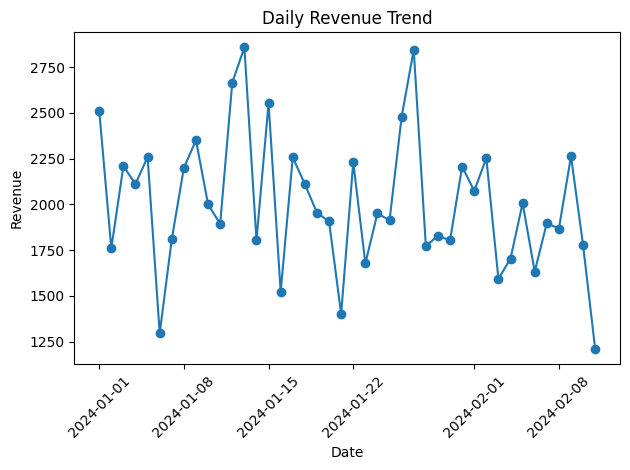

In [33]:
plt.figure()

plt.plot(
    daily_revenue['order_date'],
    daily_revenue['amount'],
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Daily Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/revenue_trend.png')

plt.show()


### **Insights**

- Revenue shows fluctuations across days, indicating varying transaction activity.
- Peaks in daily revenue suggest periods of increased purchasing behavior.
- Since only completed orders are included, the trend reflects realized revenue.
- Monitoring daily revenue helps identify seasonality, anomalies, and growth patterns.

### SQL Equivalent

```sql
SELECT
    DATE(order_date) AS date,
    SUM(amount) AS daily_revenue
FROM orders
WHERE status = 'completed'
GROUP BY DATE(order_date)
ORDER BY date;
```

### **D2 — User Revenue Analysis**

In [34]:
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = 'images'
os.makedirs(OUTPUT_DIR, exist_ok=True)

user_revenue = (
    df[df['status'] == 'completed']
    .groupby('user_id', as_index=False)
    .agg(total_revenue=('amount', 'sum'))
    .sort_values('total_revenue', ascending=False)
)

user_revenue.head()



,user_id,total_revenue
89,90,2185
61,62,2021
91,92,1659
18,19,1581
11,12,1484


In [35]:
top_users = user_revenue.head(10)

top_users

,user_id,total_revenue
89,90,2185
61,62,2021
91,92,1659
18,19,1581
11,12,1484
98,99,1476
32,33,1448
1,2,1441
47,48,1397
53,54,1365


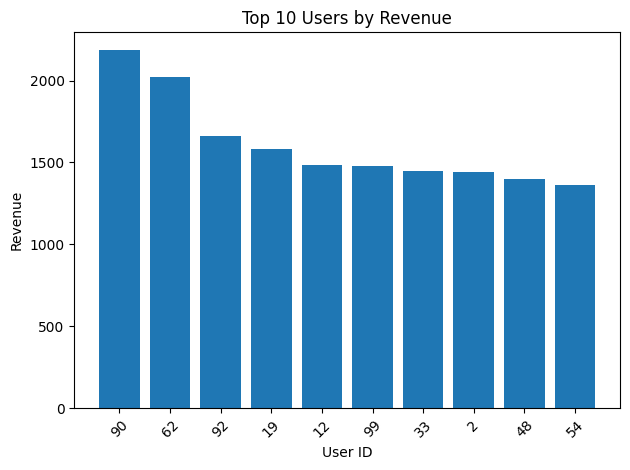

In [36]:
plt.figure()

plt.bar(
    top_users['user_id'].astype(str),
    top_users['total_revenue']
)

plt.title('Top 10 Users by Revenue')
plt.xlabel('User ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_users_revenue.png')

plt.show()

In [37]:
user_revenue['user_segment'] = pd.qcut(
    user_revenue['total_revenue'],
    q=3,
    labels=['low', 'medium', 'high']
)

user_revenue.head()

,user_id,total_revenue,user_segment
89,90,2185,high
61,62,2021,high
91,92,1659,high
18,19,1581,high
11,12,1484,high


In [38]:
segment_summary = (
    user_revenue
    .groupby('user_segment', observed=False)
    .agg(
        users=('user_id', 'count'),
        avg_revenue=('total_revenue', 'mean')
    )
    .reset_index()
)

segment_summary

,user_segment,users,avg_revenue
0,low,34,436.411765
1,medium,32,814.000000
2,high,34,1280.558824


### **Insights**

- A small group of users generates a disproportionate share of total revenue.
- High-value users contribute significantly more than the average user.
- Segmentation shows clear differences between low, medium, and high spenders.
- This distribution highlights opportunities for targeted retention and upselling strategies.

### SQL Equivalent

```sql
SELECT
    user_id,
    SUM(amount) AS total_revenue
FROM orders
WHERE status = 'completed'
GROUP BY user_id
ORDER BY total_revenue DESC
LIMIT 10;
```

## **D3 — Order Status Analysis**



In [39]:
status_counts = (
    df['status']
    .value_counts()
    .reset_index()
)

status_counts.columns = ['status', 'order_count']

status_counts

,status,order_count
0,completed,821
1,cancelled,179


### Orders by Status

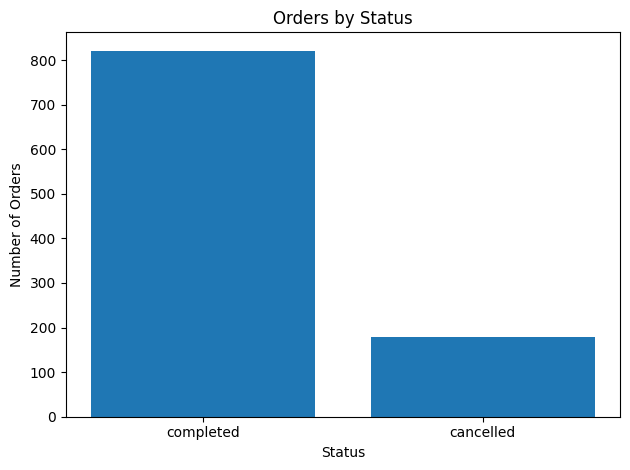

In [40]:
plt.figure()
plt.bar(status_counts['status'], status_counts['order_count'])

plt.title('Orders by Status')
plt.xlabel('Status')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/order_status_counts.png')
plt.show()

In [41]:
completion_rate = (
    (df['status'] == 'completed').mean() * 100
)

print(f'Completion rate: {completion_rate:.2f}%')

Completion rate: 82.10%


In [42]:
cancelled_rate = (df['status'] == 'cancelled').mean() * 100

print(f'Cancelled order rate: {cancelled_rate:.2f}%')

Cancelled order rate: 17.90%


### Insights

- The majority of orders are completed, indicating strong operational performance.
- The cancelled share is relatively low, suggesting limited friction in the order process.
- Completion rate shows how efficiently orders are converted into realized transactions.
- A high completion rate indicates low operational loss and stable transaction execution.
- Tracking cancellation rate is important because increases may signal issues in pricing, payment flow, or user experience.

### SQL Equivalent

```sql
SELECT
    status,
    COUNT(*) AS order_count
FROM orders
GROUP BY status;
```

### **D4 — User Spending Growth Over Time**

In [43]:
df_sorted = (
    df
    .sort_values(['user_id', 'order_date'])
)

df_sorted.head()

,order_id,user_id,order_date,amount,status
112,113,1,2024-01-05 16:00:00,171,completed
146,147,1,2024-01-07 02:00:00,41,completed
192,193,1,2024-01-09 00:00:00,118,completed
230,231,1,2024-01-10 14:00:00,113,completed
274,275,1,2024-01-12 10:00:00,163,completed


In [44]:
df_sorted['prev_amount'] = (
    df_sorted
    .groupby('user_id')['amount']
    .shift(1)
)

df_sorted.head()

,order_id,user_id,order_date,amount,status,prev_amount
112,113,1,2024-01-05 16:00:00,171,completed,NaN
146,147,1,2024-01-07 02:00:00,41,completed,171.0
192,193,1,2024-01-09 00:00:00,118,completed,41.0
230,231,1,2024-01-10 14:00:00,113,completed,118.0
274,275,1,2024-01-12 10:00:00,163,completed,113.0


```sql
LAG(amount) OVER (PARTITION BY user_id ORDER BY order_date)
```

In [45]:
df_sorted['growth_pct'] = (
    (df_sorted['amount'] - df_sorted['prev_amount'])
    / df_sorted['prev_amount']
)

In [46]:
df_sorted.loc[df_sorted['prev_amount'] == 0, 'growth_pct'] = None

In [47]:
growth_events = df_sorted[
    df_sorted['growth_pct'] >= 0.2
]

growth_events.head()

,order_id,user_id,order_date,amount,status,prev_amount,growth_pct
192,193,1,2024-01-09 00:00:00,118,completed,41.0,1.878049
274,275,1,2024-01-12 10:00:00,163,completed,113.0,0.442478
484,485,1,2024-01-21 04:00:00,158,completed,117.0,0.350427
738,739,1,2024-01-31 18:00:00,124,completed,20.0,5.200000
827,828,1,2024-02-04 11:00:00,148,completed,31.0,3.774194


In [48]:
growth_summary = (
    growth_events
    .groupby('user_id', as_index=False)
    .agg(
        growth_events_count=('growth_pct', 'count'),
        avg_growth=('growth_pct', 'mean')
    )
    .sort_values('growth_events_count', ascending=False)
)

growth_summary.head()

,user_id,growth_events_count,avg_growth
91,92,8,1.577165
15,16,7,1.577616
11,12,7,1.601757
16,17,7,1.766176
61,62,7,1.371009


### Users with Frequent Spending Growth

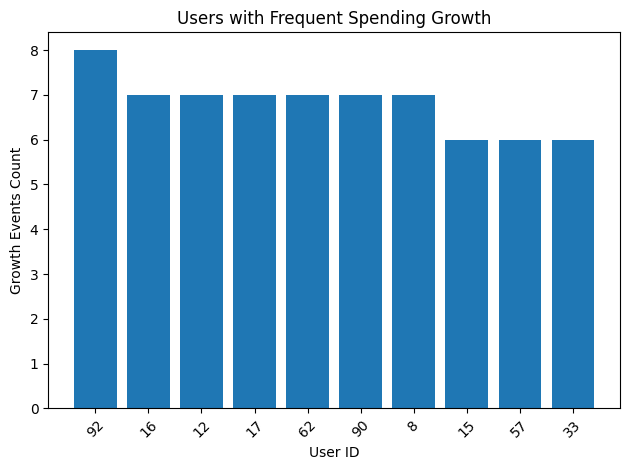

In [49]:
top_growth_users = growth_summary.head(10)

plt.figure()

plt.bar(
    top_growth_users['user_id'].astype(str),
    top_growth_users['growth_events_count']
)

plt.title('Users with Frequent Spending Growth')
plt.xlabel('User ID')
plt.ylabel('Growth Events Count')

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/growth_users.png')

plt.show()

### Insights

- Some users consistently increase their spending across transactions.
- These users represent high-potential customers with growing engagement.
- Frequent spending growth may indicate successful upselling or increasing trust in the platform.
- Identifying such users early enables targeted marketing and premium offers.
- The LAG-based approach allows tracking behavioral changes, not just aggregate metrics.

### SQL Equivalent

```sql
WITH transactions AS (
    SELECT
        user_id,
        order_date,
        amount,
        LAG(amount) OVER (
            PARTITION BY user_id
            ORDER BY order_date
        ) AS prev_amount
    FROM orders
),
growth AS (
    SELECT
        *,
        (amount - prev_amount) / prev_amount AS growth_pct
    FROM transactions
)
SELECT
    user_id,
    COUNT(*) AS growth_events_count,
    AVG(growth_pct) AS avg_growth
FROM growth
WHERE growth_pct >= 0.2
GROUP BY user_id
ORDER BY growth_events_count DESC;
```